# 📧 Email Content Quality Scoring — Model Selection + Suggestions (Google Colab)

Predict whether an email gets a **reply** from its content, pick the best model, and generate
**human-readable suggestions** ("Add a question", "Shorten the email"...) alongside the score —
the two things TheLeadFlow's `/email/quality-score` endpoint needs.

**Dataset:** balanced CSV with `subject`, `body`, engineered features
(`word_count`, `has_question`, `has_cta`, `has_link`, `personalization_level`, `num_exclamations`,
`tone`, `length_bucket`) and the target `replied` (0/1).

**Models benchmarked (5):** Logistic Regression, Random Forest, Gradient Boosting, LightGBM, XGBoost.
`ComplementNB`, `ExtraTrees`, `LinearSVC (calibrated)` and `KNN` were dropped on request.

**Selection rule:** the winner is chosen on **cross-validation ROC-AUC**, not the test score —
with ~275 test rows, test-set rankings are noisy; CV gives a more stable estimate, and the test
set is kept aside purely to report an honest final performance.

**How to run:** *Runtime ▸ Run all* — the load cell opens a file picker; upload your CSV.

## 0 · Setup

In [1]:
!pip -q install lightgbm xgboost scikit-learn pandas matplotlib

In [2]:
import warnings, joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, roc_curve, precision_recall_curve,
                             average_precision_score, confusion_matrix, classification_report)
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

RANDOM_STATE = 42
plt.rcParams["figure.dpi"] = 110

## 1 · Load (upload CSV)

In [15]:
DATA = "email_replied_dataset1.csv"   # local fallback

df = pd.read_csv(DATA)
print("Rows:", len(df))
print("Class balance:\n", df["replied"].value_counts())
df.head(3)

Rows: 1106
Class balance:
 replied
1    556
0    550
Name: count, dtype: int64


,id,subject,body,word_count,has_question,has_cta,has_link,personalization_level,num_exclamations,tone,length_bucket,replied
0,53a1b48451,Idea for Payflow's outbound,"Hello Marco,\n\nI noticed Payflow has been foc...",52,0,1,1,2,0,formal,short,1
1,87f554dac0,"Thomas, quick question about Clarity Health","Hi Thomas,\n\nI'm reaching out because we help...",49,0,0,0,1,0,casual,short,1
2,4bd2b85fce,Quick question,"Hello,\n\nWe offer a lightweight CRM add-on th...",79,1,0,0,0,0,formal,medium,1


## 2 · Features

In [16]:
# text -> TF-IDF   |   numeric/binary -> scaled   |   tone/length -> one-hot
TEXT_COL = "full_text"
NUM_COLS = ["word_count", "has_question", "has_cta", "has_link",
            "personalization_level", "num_exclamations"]
CAT_COLS = ["tone", "length_bucket"]

df = df.dropna(subset=["replied"]).reset_index(drop=True)
df["subject"] = df["subject"].fillna("")
df["body"]    = df["body"].fillna("")
df[TEXT_COL]  = df["subject"].astype(str) + " . " + df["body"].astype(str)
for col in NUM_COLS:
    df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0)

X = df[[TEXT_COL] + NUM_COLS + CAT_COLS]
y = df["replied"].astype(int).values
print("Features:", NUM_COLS, "+ TF-IDF +", CAT_COLS)
X.head(3)

Features: ['word_count', 'has_question', 'has_cta', 'has_link', 'personalization_level', 'num_exclamations'] + TF-IDF + ['tone', 'length_bucket']


,full_text,word_count,has_question,has_cta,has_link,personalization_level,num_exclamations,tone,length_bucket
0,"Idea for Payflow's outbound . Hello Marco,\n\n...",52,0,1,1,2,0,formal,short
1,"Thomas, quick question about Clarity Health . ...",49,0,0,0,1,0,casual,short
2,"Quick question . Hello,\n\nWe offer a lightwei...",79,1,0,0,0,0,formal,medium


In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE)

pre = ColumnTransformer(
    transformers=[
        ("txt", TfidfVectorizer(max_features=1500, ngram_range=(1, 2),
                                stop_words="english", min_df=2), TEXT_COL),
        ("num", MinMaxScaler(), NUM_COLS),
        ("cat", OneHotEncoder(handle_unknown="ignore"), CAT_COLS),
    ],
    sparse_threshold=0,
)
print("Train:", X_train.shape[0], " Test:", X_test.shape[0])

Train: 829  Test: 277


## 3 · Candidate models

`ComplementNB`, `ExtraTrees`, `LinearSVC (calibrated)` and `KNN` are removed as requested.
Five models remain, covering a linear baseline plus four tree/boosting variants.

In [18]:
models = {
    "LogisticRegression": LogisticRegression(max_iter=1000, C=1.0),
    "RandomForest":       RandomForestClassifier(n_estimators=400, random_state=RANDOM_STATE),
    "GradientBoosting":   GradientBoostingClassifier(random_state=RANDOM_STATE),
    "LightGBM":           LGBMClassifier(random_state=RANDOM_STATE, verbose=-1),
    "XGBoost":            XGBClassifier(random_state=RANDOM_STATE, eval_metric="logloss"),
}

## 4 · Train & evaluate

In [19]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
results, curves = [], {}

for name, clf in models.items():
    pipe = Pipeline([("pre", pre), ("clf", clf)])
    cv_auc = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="roc_auc").mean()
    pipe.fit(X_train, y_train)
    proba = pipe.predict_proba(X_test)[:, 1]
    pred  = (proba >= 0.5).astype(int)
    results.append({
        "Model":      name,
        "CV ROC-AUC": round(cv_auc, 3),
        "ROC-AUC":    round(roc_auc_score(y_test, proba), 3),
        "Accuracy":   round(accuracy_score(y_test, pred), 3),
        "Precision":  round(precision_score(y_test, pred, zero_division=0), 3),
        "Recall":     round(recall_score(y_test, pred, zero_division=0), 3),
        "F1":         round(f1_score(y_test, pred, zero_division=0), 3),
        "AvgPrec":    round(average_precision_score(y_test, proba), 3),
    })
    curves[name] = proba

res = pd.DataFrame(results).sort_values("CV ROC-AUC", ascending=False).reset_index(drop=True)
res

,Model,CV ROC-AUC,ROC-AUC,Accuracy,Precision,Recall,F1,AvgPrec
0,LogisticRegression,0.656,0.659,0.621,0.633,0.583,0.607,0.649
1,RandomForest,0.624,0.655,0.646,0.645,0.655,0.650,0.646
2,GradientBoosting,0.618,0.654,0.625,0.630,0.612,0.620,0.633
3,LightGBM,0.605,0.629,0.606,0.600,0.647,0.623,0.627
4,XGBoost,0.595,0.609,0.585,0.597,0.532,0.563,0.603


## 5 · Curves & comparison

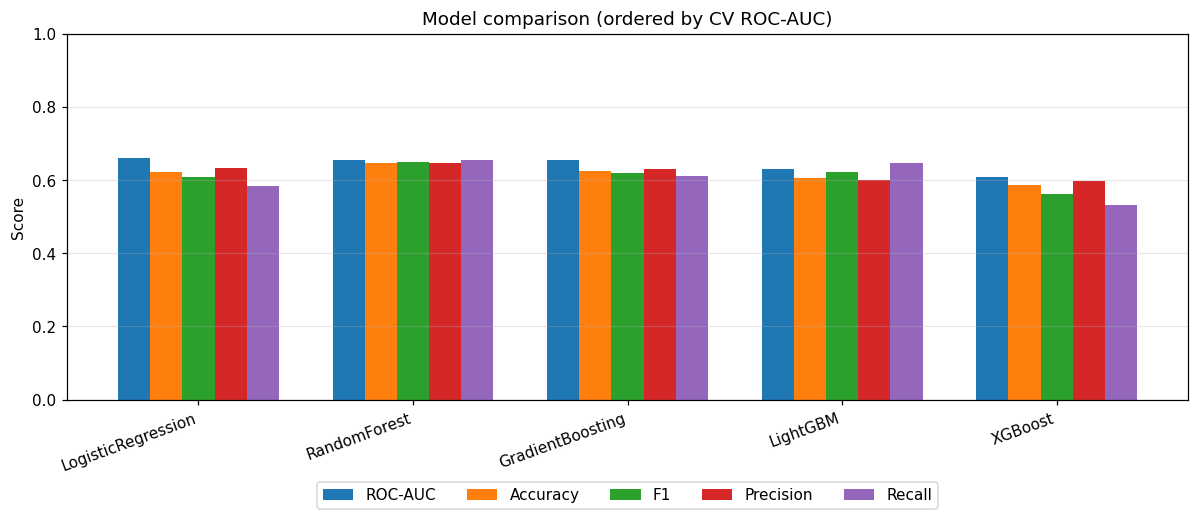

In [20]:
metrics = ["ROC-AUC", "Accuracy", "F1", "Precision", "Recall"]
order = res["Model"].tolist()
xpos = np.arange(len(order)); w = 0.15
fig, ax = plt.subplots(figsize=(11, 5))
for i, m in enumerate(metrics):
    ax.bar(xpos + i*w, res.set_index("Model").loc[order, m], w, label=m)
ax.set_xticks(xpos + w*2); ax.set_xticklabels(order, rotation=20, ha="right")
ax.set_ylim(0, 1); ax.set_ylabel("Score"); ax.set_title("Model comparison (ordered by CV ROC-AUC)")
ax.legend(ncol=5, loc="lower center", bbox_to_anchor=(0.5, -0.32)); ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()

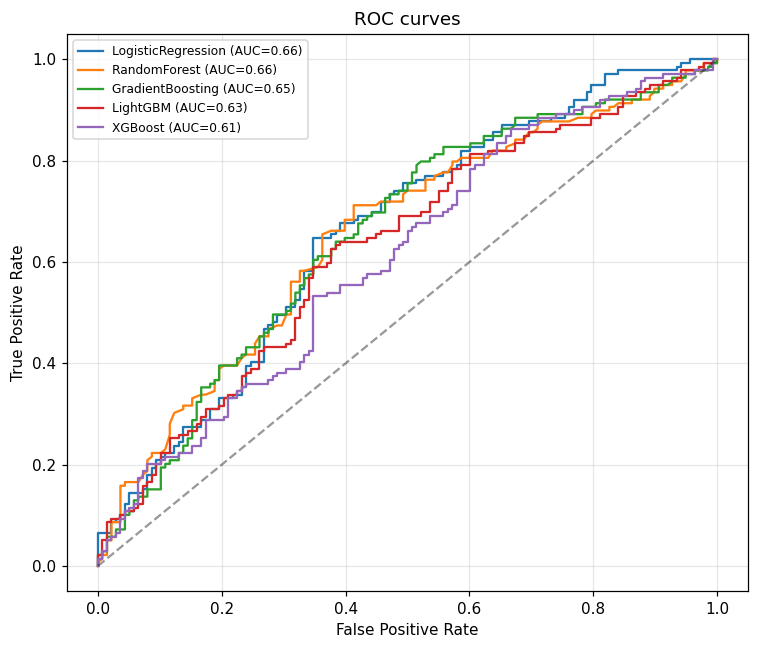

In [21]:
plt.figure(figsize=(7, 6))
for name in order:
    fpr, tpr, _ = roc_curve(y_test, curves[name])
    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_test, curves[name]):.2f})")
plt.plot([0, 1], [0, 1], "k--", alpha=0.4)
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC curves"); plt.legend(fontsize=8); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

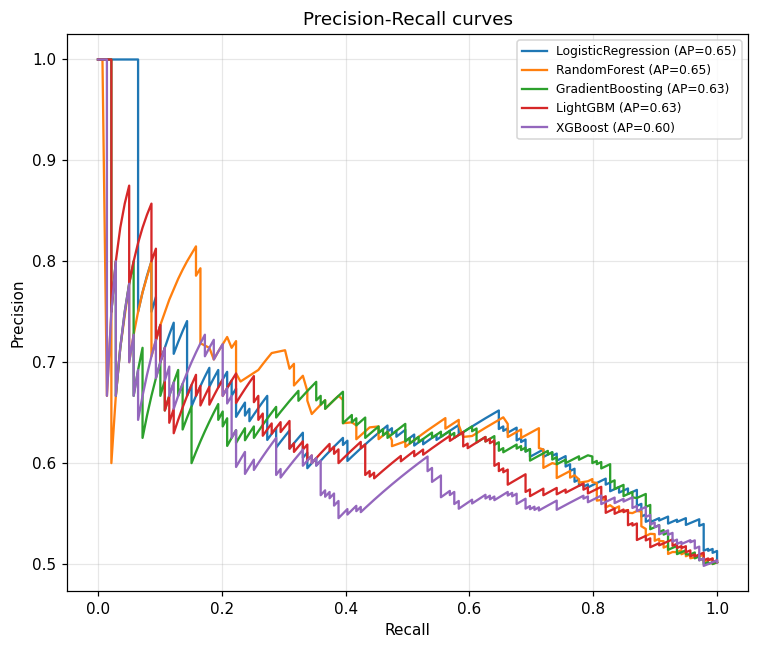

In [22]:
plt.figure(figsize=(7, 6))
for name in order:
    prec, rec, _ = precision_recall_curve(y_test, curves[name])
    plt.plot(rec, prec, label=f"{name} (AP={average_precision_score(y_test, curves[name]):.2f})")
plt.xlabel("Recall"); plt.ylabel("Precision")
plt.title("Precision-Recall curves"); plt.legend(fontsize=8); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 6 · Best model (selected on CV ROC-AUC)

Best model (CV): LogisticRegression
              precision    recall  f1-score   support

    no reply       0.61      0.66      0.63       138
     replied       0.63      0.58      0.61       139

    accuracy                           0.62       277
   macro avg       0.62      0.62      0.62       277
weighted avg       0.62      0.62      0.62       277



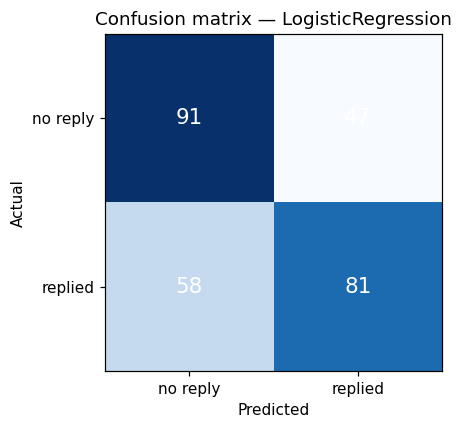

In [23]:
best_name = res.iloc[0]["Model"]
best_pipe = Pipeline([("pre", pre), ("clf", models[best_name])]).fit(X_train, y_train)
best_pred = best_pipe.predict(X_test)
print("Best model (CV):", best_name)
print(classification_report(y_test, best_pred, target_names=["no reply", "replied"]))

cm = confusion_matrix(y_test, best_pred)
fig, ax = plt.subplots(figsize=(4.5, 4))
ax.imshow(cm, cmap="Blues")
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > cm.max()/2 else "black", fontsize=14)
ax.set_xticks([0, 1]); ax.set_xticklabels(["no reply", "replied"])
ax.set_yticks([0, 1]); ax.set_yticklabels(["no reply", "replied"])
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.set_title(f"Confusion matrix — {best_name}")
plt.tight_layout(); plt.show()

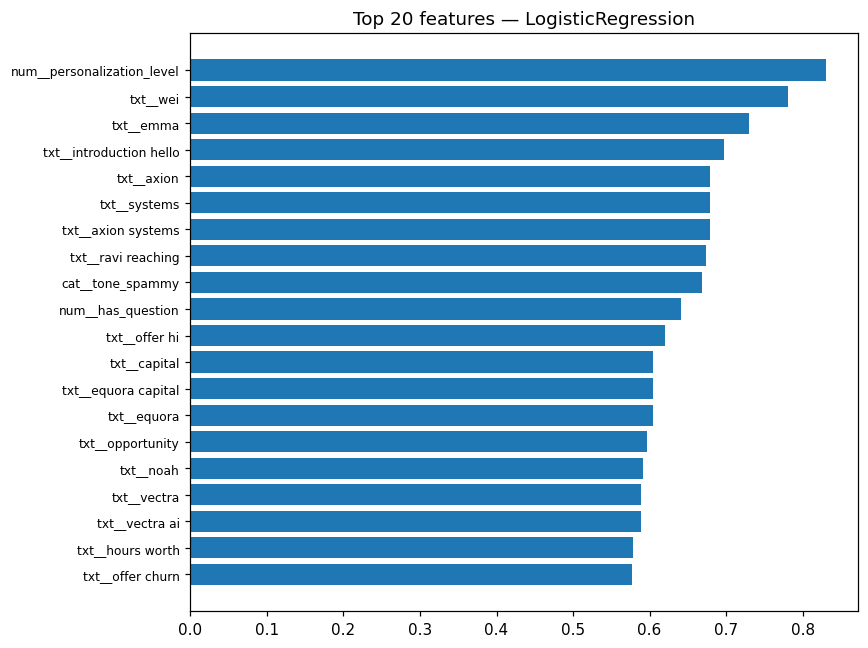

In [24]:
try:
    names = best_pipe.named_steps["pre"].get_feature_names_out()
    clf = best_pipe.named_steps["clf"]
    imp = getattr(clf, "feature_importances_", None)
    if imp is None and hasattr(clf, "coef_"):
        imp = np.abs(clf.coef_).ravel()
    if imp is not None:
        top = np.argsort(imp)[-20:]
        plt.figure(figsize=(8, 6))
        plt.barh(range(len(top)), imp[top])
        plt.yticks(range(len(top)), [names[i] for i in top], fontsize=8)
        plt.title(f"Top 20 features — {best_name}")
        plt.tight_layout(); plt.show()
    else:
        print("This model exposes no feature importances.")
except Exception as e:
    print("Importance plot skipped:", e)

## 7 · Explainability — building the suggestion engine

The score alone ("Reply likelihood: 68%") doesn't tell a salesperson *what to fix*. To generate
suggestions like *"Email too long"* or *"No question/CTA"*, we need a model whose coefficients
are directly interpretable — TF-IDF weights don't translate into clean advice.

So we fit a **second, small Logistic Regression using only the engineered features**
(`NUM_COLS` + `CAT_COLS`, no TF-IDF). Its coefficients tell us, for each feature, whether it
pushes the reply probability up or down, and by how much — regardless of which model is used for
the actual score. This keeps suggestion logic simple, stable, and data-driven (it will re-learn
correct directions automatically if you retrain on real data with different patterns).

In [25]:
interp_pre = ColumnTransformer([
    ("num", MinMaxScaler(), NUM_COLS),
    ("cat", OneHotEncoder(handle_unknown="ignore"), CAT_COLS),
])
interp_model = Pipeline([("pre", interp_pre), ("clf", LogisticRegression(max_iter=1000))])
interp_model.fit(df[NUM_COLS + CAT_COLS], y)

interp_names = interp_model.named_steps["pre"].get_feature_names_out()
interp_coefs = interp_model.named_steps["clf"].coef_.ravel()
coef_map = dict(zip(interp_names, interp_coefs))

coef_df = pd.DataFrame({"feature": interp_names, "coef": interp_coefs}) \
            .sort_values("coef", key=abs, ascending=False)
print("Learned direction of each feature (positive = increases reply probability):")
coef_df

Learned direction of each feature (positive = increases reply probability):


,feature,coef
4,num__personalization_level,1.032606
0,num__word_count,-0.698394
1,num__has_question,0.592329
8,cat__tone_spammy,-0.572863
9,cat__length_bucket_long,-0.284326
7,cat__tone_formal,0.280919
11,cat__length_bucket_short,0.278251
3,num__has_link,0.247232
2,num__has_cta,0.246501
6,cat__tone_casual,0.160567


In [26]:
def c(name, default=0.0):
    """Fetch a learned coefficient by feature name, robust to prefix (num__/cat__)."""
    for k, v in coef_map.items():
        if k.endswith(name):
            return v
    return default

# --- Suggestion rules: (condition_to_flag, coefficient_key, message) ---
def build_suggestions(feat, top_n=3):
    """feat: dict with word_count, has_question, has_cta, has_link,
    personalization_level, num_exclamations, tone, length_bucket."""
    candidates = []

    if feat["has_question"] == 0 and c("has_question") > 0:
        candidates.append((abs(c("has_question")), "Add a question to prompt a reply (e.g. \'Would this be useful for your team?\')."))
    if feat["has_cta"] == 0 and c("has_cta") > 0:
        candidates.append((abs(c("has_cta")), "Add a clear call-to-action (e.g. \'Would you be open to a 15-min call?\')."))
    if feat["personalization_level"] < 2 and c("personalization_level") > 0:
        candidates.append((abs(c("personalization_level")), "Personalize further — mention the company name and a specific pain point."))
    if feat["length_bucket"] == "long" and c("length_bucket_long") < 0:
        candidates.append((abs(c("length_bucket_long")), "Shorten the email — long emails get fewer replies."))
    if feat["length_bucket"] == "medium" and c("length_bucket_short") > 0 and feat["word_count"] > 90:
        candidates.append((abs(c("length_bucket_short")) * 0.5, "Consider trimming the email further for a punchier, shorter pitch."))
    if feat["tone"] == "spammy" and c("tone_spammy") < 0:
        candidates.append((abs(c("tone_spammy")), "Avoid urgent/spammy language (e.g. \'ACT NOW\', \'AMAZING OFFER\')."))
    if feat["num_exclamations"] >= 1 and c("num_exclamations") < 0:
        candidates.append((abs(c("num_exclamations")), "Reduce exclamation marks — they read as pushy."))
    if feat["has_link"] == 1 and c("has_link") < 0:
        candidates.append((abs(c("has_link")), "Consider removing the direct link on a first-touch email — it can read as spammy."))

    candidates.sort(key=lambda x: x[0], reverse=True)
    return [msg for _, msg in candidates[:top_n]] or ["Looks solid — no major red flags detected."]

print("Example — spammy draft:")
for s in build_suggestions({"word_count":40,"has_question":0,"has_cta":1,"has_link":0,
                            "personalization_level":0,"num_exclamations":5,
                            "tone":"spammy","length_bucket":"medium"}):
    print(" •", s)

Example — spammy draft:
 • Personalize further — mention the company name and a specific pain point.
 • Add a question to prompt a reply (e.g. 'Would this be useful for your team?').
 • Avoid urgent/spammy language (e.g. 'ACT NOW', 'AMAZING OFFER').


## 8 · Save & demo

In [27]:
final = Pipeline([("pre", pre), ("clf", models[best_name])]).fit(X, y)
joblib.dump({
    "pipeline": final,
    "interp_model": interp_model,
    "coef_map": coef_map,
    "num_cols": NUM_COLS, "cat_cols": CAT_COLS, "text_col": TEXT_COL,
    "best_name": best_name,
}, "email_quality_model.joblib")
print("Saved -> email_quality_model.joblib  (best =", best_name, ")")

try:
    from google.colab import files
    files.download("email_quality_model.joblib")
except Exception:
    pass

Saved -> email_quality_model.joblib  (best = LogisticRegression )


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [28]:
def quality_score(subject, body, word_count, has_question, has_cta, has_link,
                  personalization_level, num_exclamations, tone, length_bucket):
    row = pd.DataFrame([{
        "full_text": f"{subject} . {body}",
        "word_count": word_count, "has_question": has_question, "has_cta": has_cta,
        "has_link": has_link, "personalization_level": personalization_level,
        "num_exclamations": num_exclamations, "tone": tone, "length_bucket": length_bucket,
    }])
    score = round(float(final.predict_proba(row)[:, 1][0]) * 100, 1)
    suggestions = build_suggestions({
        "word_count": word_count, "has_question": has_question, "has_cta": has_cta,
        "has_link": has_link, "personalization_level": personalization_level,
        "num_exclamations": num_exclamations, "tone": tone, "length_bucket": length_bucket,
    })
    return score, suggestions

for label, args in [
    ("personalized + CTA + link", dict(subject="Idea for your outbound",
        body="Hi Marco, noticed your team focuses on churn. We help with exactly that. Book a slot: https://cal.com/x",
        word_count=52, has_question=0, has_cta=1, has_link=1, personalization_level=2,
        num_exclamations=0, tone="formal", length_bucket="short")),
    ("spammy", dict(subject="AMAZING OFFER!!! ACT NOW",
        body="Dear customer, our unbeatable solution guarantees results. Click now to win!!!",
        word_count=40, has_question=0, has_cta=1, has_link=0, personalization_level=0,
        num_exclamations=5, tone="spammy", length_bucket="medium")),
]:
    score, suggestions = quality_score(**args)
    print(f"[{label}] Reply likelihood: {score}%")
    for s in suggestions:
        print("   •", s)
    print()

[personalized + CTA + link] Reply likelihood: 76.1%
   • Add a question to prompt a reply (e.g. 'Would this be useful for your team?').

[spammy] Reply likelihood: 25.2%
   • Personalize further — mention the company name and a specific pain point.
   • Add a question to prompt a reply (e.g. 'Would this be useful for your team?').
   • Avoid urgent/spammy language (e.g. 'ACT NOW', 'AMAZING OFFER').



---
### Ce qui a changé par rapport à la version précédente
1. **4 modèles retirés** : `ComplementNB`, `ExtraTrees`, `LinearSVC (calibré)`, `KNN`.
2. **Sélection sur CV ROC-AUC** (pas le score de test) — plus stable avec un test de ~275 lignes.
3. **Moteur de suggestions** (§7) : une régression logistique séparée, entraînée uniquement sur
   les features manuelles, donne des coefficients interprétables par variable. `build_suggestions()`
   compare l'email soumis à ces coefficients et retourne jusqu'à 3 conseils actionnables, triés par
   impact — exactement ce qu'il faut pour l'endpoint `/email/quality-score`.
4. Le fichier sauvegardé (`email_quality_model.joblib`) contient maintenant **les deux modèles**
   (score + interprétation) et le dictionnaire de coefficients, prêt à être rechargé côté API.